# Análisis de viajes para Zuber en Chicago


## Introducción

En este notebook se desarrolla el análisis solicitado para el proyecto de Zuber en Chicago.

## Objetivo del proyecto

Identificar patrones en los viajes y evaluar una hipótesis estadística con los datos proporcionados.

## Resumen de la primera parte del proyecto

En la primera parte del Sprint 8 se realizó la preparación y obtención de datos base para el análisis:\n
\n
1. Se recuperaron datos del clima desde una página web usando `requests`, `BeautifulSoup` y `pandas`.\n
2. Se buscó la tabla HTML con `attrs={'id': 'weather_records'}`.\n
3. Se hicieron consultas SQL para analizar viajes por compañía.\n
4. Se usaron slices con `WHERE` para filtrar fechas.\n
5. Se usó `GROUP BY` y `COUNT` para contar viajes por empresa.\n
6. Se usó `INNER JOIN` entre `trips` y `cabs` usando `cab_id`.\n
7. Se usó `CASE` para clasificar empresas principales y `Other`.\n
8. Se recuperaron los identificadores de `Loop` y `O'Hare`.\n
9. Se usó `CASE` para clasificar clima como `Bad` si `description` contiene `rain` o `storm`, y `Good` en los demás casos.\n
10. Se usó `INNER JOIN` entre `trips` y `weather_records` usando `trips.start_ts = weather_records.ts` para obtener clima por viaje.

## Paso 4. Análisis exploratorio de datos


### Importación de librerías


In [1]:
# pandas: manipulación y análisis de datos tabulares
import pandas as pd

# matplotlib.pyplot: creación de gráficos para el análisis exploratorio
import matplotlib.pyplot as plt

# scipy.stats: pruebas estadísticas para la validación de hipótesis
import scipy.stats as st


### Carga de archivos CSV


In [2]:
# Cargar el archivo con viajes por compañía de taxi
company_trips = pd.read_csv('C:\CIENCIA DATOS\SPRINT 8\Sprint8_Project\Frecuencia_Uso_TaxisApp_USA\moved_project_sql_result_01.csv')

# Cargar el archivo con promedio de finalizaciones por barrio de destino
dropoff_trips = pd.read_csv('C:\CIENCIA DATOS\SPRINT 8\Sprint8_Project\Frecuencia_Uso_TaxisApp_USA\moved_project_sql_result_04.csv')

# Cargar el archivo con viajes Loop-O'Hare y condiciones climáticas
loop_ohare_trips = pd.read_csv('C:\CIENCIA DATOS\SPRINT 8\Sprint8_Project\Frecuencia_Uso_TaxisApp_USA\moved_project_sql_result_07.csv')

# Mostrar las primeras 5 filas de cada DataFrame para revisión inicial
print('Primeras 5 filas de company_trips:')
print(company_trips.head())

print('\nPrimeras 5 filas de dropoff_trips:')
print(dropoff_trips.head())

print('\nPrimeras 5 filas de loop_ohare_trips:')
print(loop_ohare_trips.head())


Primeras 5 filas de company_trips:
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                 Medallion Leasin         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299

Primeras 5 filas de dropoff_trips:
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000

Primeras 5 filas de loop_ohare_trips:
              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0


### Revisión inicial de los datos


In [3]:
# Revisión inicial de company_trips: viajes por compañía de taxi
print('--- company_trips: head() ---')
print(company_trips.head())

print('\n--- company_trips: info() ---')
company_trips.info()

print('\n--- company_trips: shape ---')
print(company_trips.shape)

print('\n--- company_trips: columns ---')
print(company_trips.columns)

print('\n--- company_trips: dtypes ---')
print(company_trips.dtypes)

print('\n--- company_trips: isna().sum() ---')
print(company_trips.isna().sum())

print('\n--- company_trips: duplicated().sum() ---')
print(company_trips.duplicated().sum())

print('\n--- company_trips: describe() ---')
print(company_trips.describe(include='all'))

# Revisión inicial de dropoff_trips: promedio de finalizaciones por barrio de destino
print('\n\n--- dropoff_trips: head() ---')
print(dropoff_trips.head())

print('\n--- dropoff_trips: info() ---')
dropoff_trips.info()

print('\n--- dropoff_trips: shape ---')
print(dropoff_trips.shape)

print('\n--- dropoff_trips: columns ---')
print(dropoff_trips.columns)

print('\n--- dropoff_trips: dtypes ---')
print(dropoff_trips.dtypes)

print('\n--- dropoff_trips: isna().sum() ---')
print(dropoff_trips.isna().sum())

print('\n--- dropoff_trips: duplicated().sum() ---')
print(dropoff_trips.duplicated().sum())

print('\n--- dropoff_trips: describe() ---')
print(dropoff_trips.describe(include='all'))

# Revisión inicial de loop_ohare_trips: viajes entre Loop y O'Hare con condición climática
print('\n\n--- loop_ohare_trips: head() ---')
print(loop_ohare_trips.head())

print('\n--- loop_ohare_trips: info() ---')
loop_ohare_trips.info()

print('\n--- loop_ohare_trips: shape ---')
print(loop_ohare_trips.shape)

print('\n--- loop_ohare_trips: columns ---')
print(loop_ohare_trips.columns)

print('\n--- loop_ohare_trips: dtypes ---')
print(loop_ohare_trips.dtypes)

print('\n--- loop_ohare_trips: isna().sum() ---')
print(loop_ohare_trips.isna().sum())

print('\n--- loop_ohare_trips: duplicated().sum() ---')
print(loop_ohare_trips.duplicated().sum())

print('\n--- loop_ohare_trips: describe() ---')
print(loop_ohare_trips.describe(include='all'))


--- company_trips: head() ---
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                 Medallion Leasin         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299

--- company_trips: info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB

--- company_trips: shape ---
(64, 2)

--- company_trips: columns ---
Index(['company_name', 'trips_amount'], dtype='object')

--- company_trips: dtypes ---
company_name    object
trips_amount     int64
dtype: object

--- company_trips: isna().sum() ---
company_name    0
trips_amount    0
dtype: int64

--- company_trips: du

### Validación de tipos de datos


In [4]:
# Validar y ajustar tipos en company_trips (texto y numerico)
if not pd.api.types.is_string_dtype(company_trips['company_name']):
    company_trips['company_name'] = company_trips['company_name'].astype('string')

if not pd.api.types.is_numeric_dtype(company_trips['trips_amount']):
    company_trips['trips_amount'] = pd.to_numeric(company_trips['trips_amount'], errors='coerce')

# Validar y ajustar tipos en dropoff_trips (texto y numerico)
if not pd.api.types.is_string_dtype(dropoff_trips['dropoff_location_name']):
    dropoff_trips['dropoff_location_name'] = dropoff_trips['dropoff_location_name'].astype('string')

if not pd.api.types.is_numeric_dtype(dropoff_trips['average_trips']):
    dropoff_trips['average_trips'] = pd.to_numeric(dropoff_trips['average_trips'], errors='coerce')

# Validar y ajustar tipos en loop_ohare_trips
# Convertir start_ts a datetime solo si aparece como object
if pd.api.types.is_object_dtype(loop_ohare_trips['start_ts']):
    loop_ohare_trips['start_ts'] = pd.to_datetime(loop_ohare_trips['start_ts'], errors='coerce')

# Asegurar weather_conditions como texto
if not pd.api.types.is_string_dtype(loop_ohare_trips['weather_conditions']):
    loop_ohare_trips['weather_conditions'] = loop_ohare_trips['weather_conditions'].astype('string')

# Asegurar duration_seconds como numerico
if not pd.api.types.is_numeric_dtype(loop_ohare_trips['duration_seconds']):
    loop_ohare_trips['duration_seconds'] = pd.to_numeric(loop_ohare_trips['duration_seconds'], errors='coerce')

# Mostrar tipos finales de los tres DataFrames despues de la validacion
print('--- dtypes de company_trips ---')
print(company_trips.dtypes)

print('\n--- dtypes de dropoff_trips ---')
print(dropoff_trips.dtypes)

print('\n--- dtypes de loop_ohare_trips ---')
print(loop_ohare_trips.dtypes)

# Revisar valores unicos de la columna weather_conditions
print('\n--- Conteo de valores en weather_conditions ---')
print(loop_ohare_trips['weather_conditions'].value_counts(dropna=False))

# Revisar valores ausentes en columnas criticas para la prueba de hipotesis
critical_cols = ['start_ts', 'weather_conditions', 'duration_seconds']
print('\n--- Valores ausentes en columnas criticas ---')
print(loop_ohare_trips[critical_cols].isna().sum())

# Mostrar las filas con ausentes en columnas criticas (si existen)
missing_critical_rows = loop_ohare_trips[loop_ohare_trips[critical_cols].isna().any(axis=1)]
print('\nTotal de filas con ausentes en columnas criticas:', missing_critical_rows.shape[0])
if not missing_critical_rows.empty:
    print(missing_critical_rows.head())


--- dtypes de company_trips ---
company_name    object
trips_amount     int64
dtype: object

--- dtypes de dropoff_trips ---
dropoff_location_name     object
average_trips            float64
dtype: object

--- dtypes de loop_ohare_trips ---
start_ts              datetime64[ns]
weather_conditions            object
duration_seconds             float64
dtype: object

--- Conteo de valores en weather_conditions ---
weather_conditions
Good    888
Bad     180
Name: count, dtype: int64

--- Valores ausentes en columnas criticas ---
start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64

Total de filas con ausentes en columnas criticas: 0


Si se detectan valores ausentes en `start_ts`, `weather_conditions` o `duration_seconds`, primero se documentaran (como en la celda anterior) y despues, para la prueba de hipotesis, se eliminaran unicamente esas filas con datos criticos faltantes. Si no hay ausentes en esas columnas, no se eliminara ninguna fila.

### Identificación de los 10 principales barrios de destino


In [5]:
# Slice 1: ordenar company_trips por cantidad de viajes en orden descendente
company_trips_sorted = company_trips.sort_values(by='trips_amount', ascending=False)

# Slice 2: obtener los 10 barrios con mayor promedio de finalizaciones
top_10_dropoff_locations = dropoff_trips.sort_values(by='average_trips', ascending=False).head(10)

# Slice 3: duracion de viajes cuando el clima es Bad (para la prueba de hipotesis)
bad_weather_duration = loop_ohare_trips.loc[
    loop_ohare_trips['weather_conditions'] == 'Bad', 'duration_seconds'
]

# Slice 4: duracion de viajes cuando el clima es Good (para la prueba de hipotesis)
good_weather_duration = loop_ohare_trips.loc[
    loop_ohare_trips['weather_conditions'] == 'Good', 'duration_seconds'
]

# Mostrar primeras filas de los slices del analisis exploratorio
print('Primeras filas de company_trips_sorted:')
print(company_trips_sorted.head())

print('\nPrimeras filas de top_10_dropoff_locations:')
print(top_10_dropoff_locations.head())

# Mostrar la cantidad de registros en los slices para la prueba de hipotesis
print('\nCantidad de registros en bad_weather_duration:', len(bad_weather_duration))
print('Cantidad de registros en good_weather_duration:', len(good_weather_duration))


Primeras filas de company_trips_sorted:
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                 Medallion Leasin         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299

Primeras filas de top_10_dropoff_locations:
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000

Cantidad de registros en bad_weather_duration: 180
Cantidad de registros en good_weather_duration: 888


### Gráfico: empresas de taxi y número de viajes


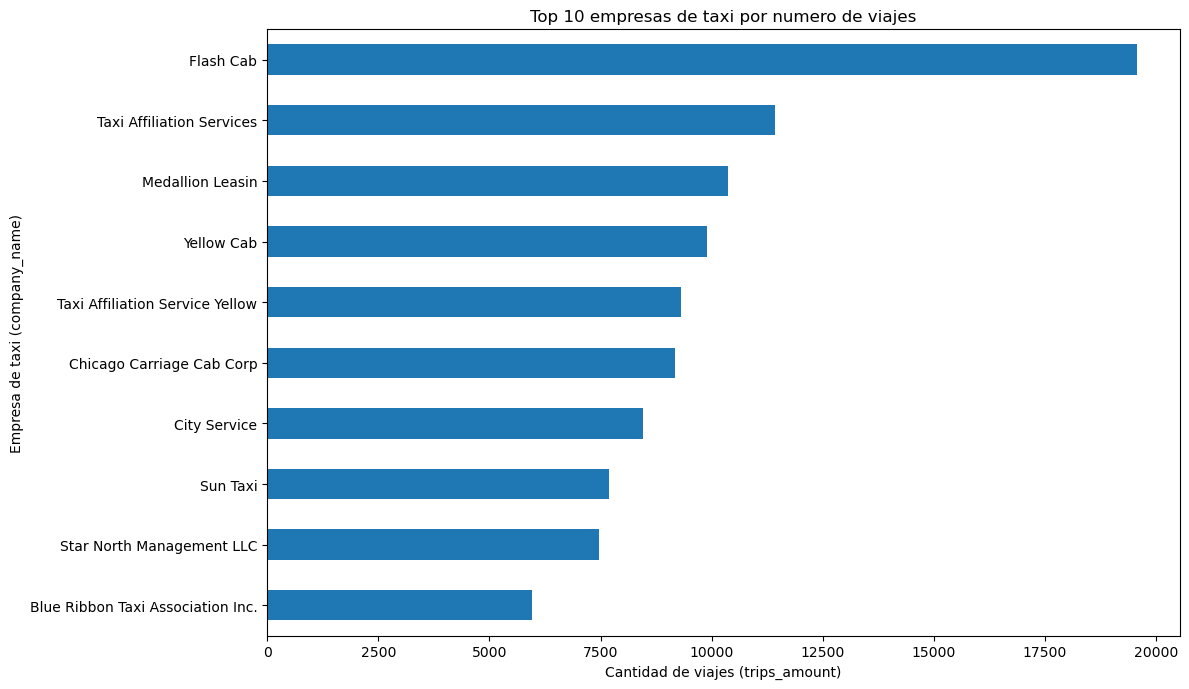

In [6]:
# Seleccionar las 10 principales empresas para un grafico legible
top_10_companies = company_trips_sorted.head(10).sort_values(by='trips_amount', ascending=True)

# Crear un grafico de barras horizontal con nombre de empresa en Y y viajes en X
top_10_companies.plot(
    kind='barh',
    x='company_name',
    y='trips_amount',
    figsize=(12, 7),
    legend=False
)

# Configurar titulo y etiquetas de ejes
plt.title('Top 10 empresas de taxi por numero de viajes')
plt.xlabel('Cantidad de viajes (trips_amount)')
plt.ylabel('Empresa de taxi (company_name)')
plt.tight_layout()
plt.show()


En este grafico se observa que **Flash Cab** lidera en cantidad de viajes. Tambien se aprecia una concentracion de viajes en pocas empresas principales, con una diferencia clara respecto al resto del top 10. Para Zuber, esto puede significar que competir o colaborar estrategicamente con los actores mas fuertes del mercado puede ser clave para ganar participacion.

### Gráfico: top 10 barrios por número promedio de finalizaciones


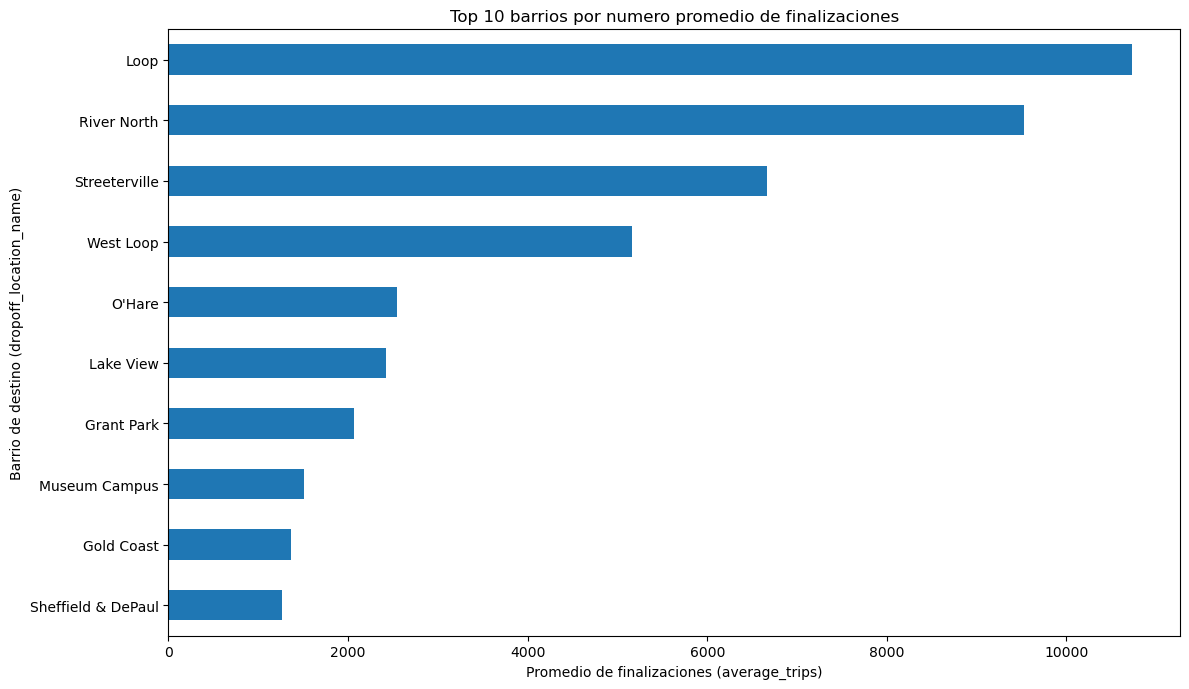

In [7]:
# Ordenar el top 10 de barrios para visualizarlo en barras horizontales
top_10_dropoff_plot = top_10_dropoff_locations.sort_values(by='average_trips', ascending=True)

# Crear grafico de barras horizontal con barrios en Y y promedio de finalizaciones en X
top_10_dropoff_plot.plot(
    kind='barh',
    x='dropoff_location_name',
    y='average_trips',
    figsize=(12, 7),
    legend=False
)

# Configurar titulo y etiquetas de ejes
plt.title('Top 10 barrios por numero promedio de finalizaciones')
plt.xlabel('Promedio de finalizaciones (average_trips)')
plt.ylabel('Barrio de destino (dropoff_location_name)')
plt.tight_layout()
plt.show()


En este grafico destacan **Loop**, **River North** y **Streeterville** como los barrios con mas finalizaciones. Estos barrios representan zonas importantes de demanda de viajes en la ciudad. Para Zuber, esto puede significar que enfocar disponibilidad de conductores y estrategias comerciales en estas areas puede mejorar cobertura y volumen de viajes.

### Conclusiones del análisis exploratorio

1. **Empresas de taxi y competencia:** Los datos muestran que **Flash Cab** lidera en número de viajes y que existe una concentración relevante en pocas compañías del mercado, lo que sugiere un entorno competitivo con actores dominantes.\n
\n
2. **Barrios con mayor promedio de finalizaciones:** En el top 10 destacan **Loop**, **River North** y **Streeterville**, lo que confirma que estas zonas concentran una parte importante de la demanda de traslados.\n
\n
3. **Interpretación general para Zuber:** Para mejorar su posición, Zuber puede priorizar cobertura operativa y estrategia comercial en zonas de alta demanda y, al mismo tiempo, considerar la presión competitiva de las empresas con mayor volumen de viajes.

## Paso 5. Prueba de hipótesis


### Preparación de los datos


In [8]:
# Preparar una copia con las columnas criticas para la prueba de hipotesis
hypothesis_data = loop_ohare_trips[['start_ts', 'weather_conditions', 'duration_seconds']].copy()

# Revisar valores ausentes en columnas criticas antes de crear los grupos
print('Valores ausentes antes de filtrar:')
print(hypothesis_data.isna().sum())

# Eliminar solo filas con ausentes en columnas criticas para la prueba
hypothesis_data = hypothesis_data.dropna(subset=['start_ts', 'weather_conditions', 'duration_seconds'])

# Crear los dos grupos independientes a comparar en la prueba t
bad_weather_duration = hypothesis_data.loc[
    hypothesis_data['weather_conditions'] == 'Bad', 'duration_seconds'
]
good_weather_duration = hypothesis_data.loc[
    hypothesis_data['weather_conditions'] == 'Good', 'duration_seconds'
]

# Confirmar el tamaño de ambos grupos ya preparados
print('\nRegistros en grupo Bad:', len(bad_weather_duration))
print('Registros en grupo Good:', len(good_weather_duration))


Valores ausentes antes de filtrar:
start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64

Registros en grupo Bad: 180
Registros en grupo Good: 888


### Planteamiento de hipótesis

Para el proyecto se evaluara la siguiente afirmacion: **"La duracion promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sabados lluviosos"**.\n
\n
**H0 (hipotesis nula):** La duracion promedio de los viajes desde Loop hasta O'Hare es igual en sabados con buen clima y en sabados con mal clima.\n
\n
**H1 (hipotesis alternativa):** La duracion promedio de los viajes desde Loop hasta O'Hare es diferente en sabados con buen clima y en sabados con mal clima.\n
\n
Se aplicara una **prueba de dos colas** porque la palabra "cambia" indica diferencia entre medias, pero no especifica direccion (no afirma solo aumento ni solo disminucion).

### Criterio estadístico

Para contrastar la hipotesis, se compararan dos grupos independientes:\n
- viajes con `weather_conditions == 'Bad'`\n
- viajes con `weather_conditions == 'Good'`\n
\n
Se utilizara `scipy.stats.ttest_ind` porque se desea comparar las medias de dos muestras independientes.\n
\n
En la prueba se usara `equal_var=False`, ya que no se asume que ambas muestras tengan la misma varianza.\n
\n
El nivel de significacion sera `alpha = 0.05`.\n
\n
Regla de decision:\n
- Si `p_value < alpha`, se rechaza H0.\n
- Si `p_value >= alpha`, no se puede rechazar H0.

### Aplicación de la prueba t


In [9]:
# Limpiar valores ausentes en las series de duracion antes de la prueba
bad_weather_duration = bad_weather_duration.dropna()
good_weather_duration = good_weather_duration.dropna()

# Mostrar el tamaño de cada grupo
print('Tamano del grupo Bad:', len(bad_weather_duration))
print('Tamano del grupo Good:', len(good_weather_duration))

# Mostrar el promedio de duracion de cada grupo
print('\nPromedio de duracion (Bad):', bad_weather_duration.mean())
print('Promedio de duracion (Good):', good_weather_duration.mean())

# Mostrar la varianza de duracion de cada grupo
print('\nVarianza de duracion (Bad):', bad_weather_duration.var())
print('Varianza de duracion (Good):', good_weather_duration.var())

# Definir el nivel de significacion
alpha = 0.05

# Aplicar la prueba t para dos muestras independientes sin asumir varianzas iguales
results = st.ttest_ind(bad_weather_duration, good_weather_duration, equal_var=False)

# Mostrar el p-value de la prueba
print('\np_value:', results.pvalue)

# Tomar decision estadistica segun el valor de p y alpha
if results.pvalue < alpha:
    print('Rechazamos la hipótesis nula')
else:
    print('No podemos rechazar la hipótesis nula')


Tamano del grupo Bad: 180
Tamano del grupo Good: 888

Promedio de duracion (Bad): 2427.2055555555557
Promedio de duracion (Good): 1999.6756756756756

Varianza de duracion (Bad): 520294.08600248274
Varianza de duracion (Good): 576382.0096895089

p_value: 6.738994326108734e-12
Rechazamos la hipótesis nula


### Conclusión de la prueba de hipótesis

Con un nivel de significacion de `alpha = 0.05`, el resultado de la prueba arroja `p_value = 6.738994326108735e-12`, que es menor que `alpha`. Por lo tanto, **se rechaza la hipotesis nula**. Esto indica evidencia estadistica de que la duracion promedio de los viajes desde Loop hasta O'Hare **si cambia** en sabados con mal clima frente a sabados con buen clima.

## Conclusión general

El analisis exploratorio muestra que el mercado de viajes presenta concentración en pocas empresas, con **Flash Cab** como líder en en mayor número de viajes. En paralelo, los datos de destinos indican que **Loop**, **River North** y **Streeterville** se ubican entre los barrios con mayor promedio de viajes finalizados, lo que confirma zonas de demanda elevada. En la prueba de hipótesis, con `alpha = 0.05`, se obtuvo un `p_value` menor que `alpha`, por lo que se rechazo la hipotesis nula y se concluyo que la duracion promedio de los viajes Loop-O'Hare cambia entre sabados con buen y mal clima. En conjunto, estos resultados describen un entorno competitivo concentrado, con demanda focalizada por zonas y sensible a las condiciones climaticas durante el viaje. Talvez estrategias con los conductores en día de lluvia donde esten más diponibles para satisfacer la demanda. Complementar con análisis de tarifas buscando un punto medio. Incrementar la disponibilidad de vehículos en los barrios más frecuentes o hasta ofrecer estrategias tipo auto pull en días lluviosos con mayor ganancia para el conductor y ahorros del usuario en el mismo trayecto.
